# ACT DualTF: Counterexample Generation with VNNLib

This notebook demonstrates:
1. **Model Loading**: Load VNNLib benchmarks with preprocessing
2. **Forward Bounds**: Compute bounds using IntervalTF
3. **Counterexample Generation**: Use DualTF to generate spurious counterexamples (SCE)
4. **Visualization**: Display and analyze counterexamples

## Step 1: Setup and Imports

In [2]:
# Setup and imports
import sys, os
import io
from contextlib import redirect_stdout

f = io.StringIO()
with redirect_stdout(f):
    from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
    from act.front_end.model_synthesis import synthesize_models_from_specs
    
act_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
sys.path.insert(0, act_root) if act_root not in sys.path else None

import torch
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Force reload modules
import importlib
modules_to_reload = [
    'act.front_end.model_synthesis',
    'act.front_end.vnnlib_loader.create_specs',
    'act.pipeline.verification.torch2act',
    'act.back_end.dual_tf',
]
for mod_name in modules_to_reload:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

from act.front_end.vnnlib_loader.create_specs import VNNLibSpecCreator
from act.front_end.model_synthesis import synthesize_models_from_specs
from act.pipeline.verification.torch2act import TorchToACT
from act.back_end.dual_tf import DualTF, compute_forward_bounds

# CIFAR-100 class names
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

print("Setup complete")

Setup complete


## Step 2: Load VNNLib Benchmark and Synthesize Models

In [2]:
print("="*80)
print("LOADING CIFAR-100 VNNLIB BENCHMARK")
print("="*80)

# Load VNNLib instances
creator = VNNLibSpecCreator(config_name="vnnlib_default")
spec_results = creator.create_specs_for_data_model_pairs(
    categories=["cifar100_2024"],
    max_instances=3,
    validate_shapes=True
)
print(f"Loaded {len(spec_results)} instances\n")

# Synthesize wrapped models
print("Synthesizing wrapped models...")
wrapped_models, reports = synthesize_models_from_specs(spec_results)
print(f"Synthesized {len(wrapped_models)} wrapped models\n")

# Extract instance info for all models
instance_info = []
wrapped_models_list = list(wrapped_models.values())
combo_ids = list(wrapped_models.keys())

for idx, (combo_id, wrapped_model) in enumerate(wrapped_models.items()):
    input_layer = wrapped_model[0]
    labeled_input = input_layer.labeled_input
    input_spec_layer = wrapped_model[1]
    input_spec = input_spec_layer.spec
    epsilon = float((input_spec.ub - input_spec.lb).max())
    
    instance_info.append({
        'index': idx,
        'combo_id': combo_id,
        'input_tensor': labeled_input.tensor,
        'true_label': labeled_input.label,
        'epsilon': epsilon,
        'input_spec': input_spec,
        'labeled_input': labeled_input
    })
    
    class_name = CIFAR100_CLASSES[labeled_input.label] if labeled_input.label < len(CIFAR100_CLASSES) else "unknown"
    print(f"Instance {idx + 1}: {class_name} (label={labeled_input.label}), eps={epsilon:.6f}")

print(f"\nReady for counterexample generation")

INFO:act.front_end.vnnlib_loader.create_specs:Creating VNNLIB specs: categories=['cifar100_2024'], max_instances=3
INFO:act.front_end.vnnlib_loader.create_specs:Processing 3 VNNLIB instances
INFO:act.front_end.vnnlib_loader.create_specs:Loading instance: cifar100_2024/CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_116_sidx_8002_eps_0.0039
INFO:act.front_end.vnnlib_loader.data_model_loader:Loading VNNLIB instance: cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.data_model_loader:[1/3] Converting ONNX model to PyTorch...
INFO:act.front_end.vnnlib_loader.onnx_converter:Loading ONNX model from /data1/guanqin/newACT/ACT/data/vnnlib/cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.onnx_converter:Converting ONNX to PyTorch
INFO:act.front_end.vnnlib_loader.onnx_converter:Converted model to device=cpu, dtype=torch.float64
INFO:act.front_end.vnnlib_loader.onnx_converter:Successfully converted ONNX model: CIFAR100_resnet_mediu

LOADING CIFAR-100 VNNLIB BENCHMARK


INFO:act.front_end.vnnlib_loader.create_specs:Loading instance: cifar100_2024/CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_4071_sidx_6244_eps_0.0039
INFO:act.front_end.vnnlib_loader.data_model_loader:Loading VNNLIB instance: cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.data_model_loader:[1/3] Converting ONNX model to PyTorch...
INFO:act.front_end.vnnlib_loader.onnx_converter:Loading ONNX model from /data1/guanqin/newACT/ACT/data/vnnlib/cifar100_2024/onnx/CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.onnx_converter:Converting ONNX to PyTorch
INFO:act.front_end.vnnlib_loader.onnx_converter:Converted model to device=cpu, dtype=torch.float64
INFO:act.front_end.vnnlib_loader.onnx_converter:Successfully converted ONNX model: CIFAR100_resnet_medium.onnx
INFO:act.front_end.vnnlib_loader.data_model_loader:  ✓ Model converted successfully
INFO:act.front_end.vnnlib_loader.data_model_loader:[2/3] Extracting input shape...
INFO:act.front_e

Loaded 3 instances

Synthesizing wrapped models...

🧬 Synthesizing models from 3 spec result(s)...
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_116_sidx_8002_eps_0.0039: Created 1 wrapped model(s)
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_4071_sidx_6244_eps_0.0039: Created 1 wrapped model(s)
✓ cifar100_2024 + CIFAR100_resnet_medium_CIFAR100_resnet_medium_prop_idx_1862_sidx_1111_eps_0.0039: Created 1 wrapped model(s)

🎉 Synthesized 3 wrapped models from specs!
Synthesized 3 wrapped models

Instance 1: tank (label=85), eps=0.030590
Instance 2: shrew (label=74), eps=0.030590
Instance 3: table (label=84), eps=0.030590

Ready for counterexample generation


## Step 3: Select Instance for Analysis

In [3]:
# Select instance to analyze (change this index to test different instances)
INSTANCE_IDX = 0

info = instance_info[INSTANCE_IDX]
wrapped_model = wrapped_models_list[INSTANCE_IDX]
true_label = info['true_label']
epsilon = info['epsilon']
input_tensor = info['input_tensor']

print("="*80)
print(f"ANALYZING INSTANCE {INSTANCE_IDX + 1}")
print("="*80)
print(f"True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print(f"Epsilon: {epsilon:.6f}")
print(f"Input shape: {input_tensor.shape}")

ANALYZING INSTANCE 1
True label: 85 (tank)
Epsilon: 0.030590
Input shape: torch.Size([1, 3, 32, 32])


## Step 4: Convert to ACT Format

In [4]:
print("Converting to ACT format...")

# Convert wrapped model to ACT format
converter = TorchToACT(wrapped_model)
act_net = converter.run()

print(f"ACT network created with {len(act_net.layers)} layers")
for i, layer in enumerate(act_net.layers):
    print(f"  Layer {i}: {layer.kind}")

Converting to ACT format...
ACT network created with 73 layers
  Layer 0: INPUT
  Layer 1: INPUT_SPEC
  Layer 2: CONV2D
  Layer 3: SCALE
  Layer 4: BIAS
  Layer 5: RELU
  Layer 6: CONV2D
  Layer 7: SCALE
  Layer 8: BIAS
  Layer 9: RELU
  Layer 10: CONV2D
  Layer 11: SCALE
  Layer 12: BIAS
  Layer 13: CONV2D
  Layer 14: SCALE
  Layer 15: BIAS
  Layer 16: CONV2D
  Layer 17: SCALE
  Layer 18: BIAS
  Layer 19: RELU
  Layer 20: CONV2D
  Layer 21: SCALE
  Layer 22: BIAS
  Layer 23: CONV2D
  Layer 24: SCALE
  Layer 25: BIAS
  Layer 26: RELU
  Layer 27: CONV2D
  Layer 28: SCALE
  Layer 29: BIAS
  Layer 30: CONV2D
  Layer 31: SCALE
  Layer 32: BIAS
  Layer 33: RELU
  Layer 34: CONV2D
  Layer 35: SCALE
  Layer 36: BIAS
  Layer 37: CONV2D
  Layer 38: SCALE
  Layer 39: BIAS
  Layer 40: RELU
  Layer 41: CONV2D
  Layer 42: SCALE
  Layer 43: BIAS
  Layer 44: CONV2D
  Layer 45: SCALE
  Layer 46: BIAS
  Layer 47: CONV2D
  Layer 48: SCALE
  Layer 49: BIAS
  Layer 50: RELU
  Layer 51: CONV2D
  Layer 52: 

## Step 5: Compute Forward Bounds (IntervalTF)

In [5]:
print("="*80)
print("COMPUTING FORWARD BOUNDS")
print("="*80)

# Compute forward bounds using IntervalTF
# Get input bounds from specification
input_spec = info['input_spec']
input_lb = input_spec.lb.flatten()
input_ub = input_spec.ub.flatten()

print(f"Input bounds: lb=[{input_lb.min():.4f}, {input_lb.max():.4f}], ub=[{input_ub.min():.4f}, {input_ub.max():.4f}]")

print("\nRunning forward interval propagation...")
bounds_dict = compute_forward_bounds(act_net, input_lb, input_ub)

print(f"\nComputed bounds for {len(bounds_dict)} layers")

# Analyze bound statistics
layer_stats = []
for layer in act_net.layers:
    if layer.id in bounds_dict:
        bounds = bounds_dict[layer.id]
        width = (bounds.ub - bounds.lb).abs()
        layer_stats.append({
            'layer': layer.kind,
            'shape': bounds.lb.shape,
            'width_mean': width.mean().item(),
            'width_max': width.max().item()
        })

print(f"\nBound propagation summary:")
print(f"  Input bound width (mean): {layer_stats[0]['width_mean']:.6f}")
print(f"  Output bound width (mean): {layer_stats[-1]['width_mean']:.6f}")
expansion_ratio = layer_stats[-1]['width_mean'] / (layer_stats[0]['width_mean'] + 1e-10)
print(f"  Bound expansion ratio: {expansion_ratio:.2f}x")

# Store output bounds for DualTF
output_layer = act_net.layers[-2]  # Before ASSERT
output_bounds = bounds_dict.get(output_layer.id)
if output_bounds:
    print(f"\nOutput layer bounds:")
    print(f"  Shape: {output_bounds.lb.shape}")
    print(f"  Lower bound range: [{output_bounds.lb.min().item():.4f}, {output_bounds.lb.max().item():.4f}]")
    print(f"  Upper bound range: [{output_bounds.ub.min().item():.4f}, {output_bounds.ub.max().item():.4f}]")

COMPUTING FORWARD BOUNDS
Input bounds: lb=[-1.8824, 1.9682], ub=[-1.8531, 1.9966]

Running forward interval propagation...

Computed bounds for 73 layers

Bound propagation summary:
  Input bound width (mean): 0.029446
  Output bound width (mean): 0.000000
  Bound expansion ratio: 0.00x

Output layer bounds:
  Shape: torch.Size([100])
  Lower bound range: [-3.0816, -0.2668]
  Upper bound range: [-3.0816, -0.2668]


## Step 6: DualTF Verification and Counterexample Generation

In [6]:
print("="*80)
print("DUAL TF VERIFICATION")
print("="*80)

dual_tf = DualTF()
num_classes = 100

# Compute robust bound
min_margin, is_certified = dual_tf.compute_robust_bound(act_net, bounds_dict, true_label, num_classes)

print(f"\nRobust verification result:")
print(f"  True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Status: {'CERTIFIED ROBUST' if is_certified else 'NOT CERTIFIED'}")

if not is_certified:
    print(f"\n  The model is vulnerable to adversarial attacks within epsilon={epsilon:.6f}")
else:
    print(f"\n  The model is guaranteed robust within epsilon={epsilon:.6f}")

DUAL TF VERIFICATION

Robust verification result:
  True label: 85 (tank)
  Min margin: -2.224983
  Status: NOT CERTIFIED

  The model is vulnerable to adversarial attacks within epsilon=0.030590


## Step 7: Per-Class Margin Analysis

In [7]:
print("\n" + "="*80)
print("PER-CLASS MARGIN ANALYSIS")
print("="*80)

margins = []
for target_class in range(num_classes):
    if target_class == true_label:
        continue
    
    # Create objective: c[true_label] - c[target_class]
    c = torch.zeros(num_classes, dtype=output_bounds.lb.dtype, device=output_bounds.lb.device)
    c[true_label] = 1.0
    c[target_class] = -1.0
    
    margin = dual_tf.compute_bound(act_net, bounds_dict, c)
    margins.append((target_class, margin.item()))

# Sort by margin (most vulnerable first)
margins.sort(key=lambda x: x[1])

print(f"\nTop 10 most vulnerable classes:")
for i, (target_class, margin) in enumerate(margins[:10]):
    status = "OK" if margin > 0 else "VULNERABLE"
    print(f"  {i+1}. Class {target_class:3d} ({CIFAR100_CLASSES[target_class]:20s}): margin = {margin:8.4f} [{status}]")

# Find weakest class for counterexample generation
weakest_class, weakest_margin = margins[0]
print(f"\nWeakest class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")
print(f"Margin: {weakest_margin:.6f}")


PER-CLASS MARGIN ANALYSIS

Top 10 most vulnerable classes:
  1. Class  99 (worm                ): margin =  -2.2250 [VULNERABLE]
  2. Class  10 (bowl                ): margin =  -1.8284 [VULNERABLE]
  3. Class  61 (plate               ): margin =  -1.7528 [VULNERABLE]
  4. Class  78 (snake               ): margin =  -1.5903 [VULNERABLE]
  5. Class  51 (mushroom            ): margin =  -1.5691 [VULNERABLE]
  6. Class   8 (bicycle             ): margin =  -1.4912 [VULNERABLE]
  7. Class  32 (flatfish            ): margin =  -1.4247 [VULNERABLE]
  8. Class  24 (cockroach           ): margin =  -1.3907 [VULNERABLE]
  9. Class  54 (orchid              ): margin =  -1.3667 [VULNERABLE]
  10. Class  66 (raccoon             ): margin =  -1.3347 [VULNERABLE]

Weakest class: 99 (worm)
Margin: -2.224983


## Step 8: Generate Counterexample (SCE)

In [10]:
print("\n" + "="*80)
print("GENERATING COUNTEREXAMPLE (SCE)")
print("="*80)

# Create objective for weakest class
c = torch.zeros(num_classes, dtype=output_bounds.lb.dtype, device=output_bounds.lb.device)
c[true_label] = 1.0
c[weakest_class] = -1.0

# Compute bound with SCE
margin, sce_raw = dual_tf.compute_bound(act_net, bounds_dict, c, return_sce=True)

# #region agent log
import json, time
with open('/home/guanqinzhang/guanqin/newACT/ACT/.cursor/debug.log', 'a') as f: 
    f.write(json.dumps({
        'sessionId':'debug-session',
        'runId':'pre-fix',
        'hypothesisId':'H2',
        'location':'sce_gen:after_compute_bound',
        'message':'SCE raw from DualTF',
        'data':{'sce_raw_shape':str(sce_raw.shape),'sce_raw_numel':sce_raw.numel(),'expected_size':3*32*32},
        'timestamp':int(time.time()*1000)
    }) + '\n')
# #endregion

print(f"Target adversarial class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")
print(f"DualTF margin: {margin.item():.6f}")
print(f"SCE raw shape: {sce_raw.shape}")

# Handle SCE shape mismatch - reconstruct using input bounds if needed
expected_size = 3 * 32 * 32  # 3072 for CIFAR images
if sce_raw.numel() != expected_size:
    print(f"SCE size mismatch ({sce_raw.numel()} vs {expected_size}), using input bounds for reconstruction...")
    input_layer = act_net.layers[1]  # INPUT_SPEC layer
    input_bounds = bounds_dict.get(input_layer.id)
    if input_bounds is not None:
        # Use lower bound as counterexample (greedy selection)
        sce_image = input_bounds.lb.clone().reshape(1, 3, 32, 32)
        # #region agent log
        with open('/home/guanqinzhang/guanqin/newACT/ACT/.cursor/debug.log', 'a') as f:
            f.write(json.dumps({
                'sessionId':'debug-session',
                'runId':'post-fix',
                'hypothesisId':'H1-FIX',
                'location':'sce_gen:after_reshape_fix',
                'message':'Applied reshape fix to input_bounds.lb',
                'data':{'sce_image_shape':str(sce_image.shape)},
                'timestamp':int(time.time()*1000)
            }) + '\n')
        # #endregion
        # #region agent log
        with open('/home/guanqinzhang/guanqin/newACT/ACT/.cursor/debug.log', 'a') as f:
            f.write(json.dumps({
                'sessionId':'debug-session',
                'runId':'pre-fix',
                'hypothesisId':'H1,H3,H4',
                'location':'sce_gen:after_clone',
                'message':'SCE from input_bounds.lb',
                'data':{
                    'sce_image_shape':str(sce_image.shape),
                    'input_bounds_lb_shape':str(input_bounds.lb.shape),
                    'input_tensor_shape':str(input_tensor.shape)
                },
                'timestamp':int(time.time()*1000)
            }) + '\n')
        # #endregion
        print(f"Using input lower bound as SCE")
    else:
        print("ERROR: Cannot reconstruct SCE - no input bounds available")
        sce_image = input_tensor.clone()  # Already correct shape
        # #region agent log
        with open('/home/guanqinzhang/guanqin/newACT/ACT/.cursor/debug.log', 'a') as f:
            f.write(json.dumps({
                'sessionId':'debug-session',
                'runId':'pre-fix',
                'hypothesisId':'H5',
                'location':'sce_gen:fallback_to_input',
                'message':'Using input_tensor as fallback',
                'data':{'sce_image_shape':str(sce_image.shape)},
                'timestamp':int(time.time()*1000)
            }) + '\n')
        # #endregion
else:
    sce_image = sce_raw.reshape(1, 3, 32, 32)
    # #region agent log
    with open('/home/guanqinzhang/guanqin/newACT/ACT/.cursor/debug.log', 'a') as f:
        f.write(json.dumps({
            'sessionId':'debug-session',
            'runId':'pre-fix',
            'hypothesisId':'H3',
            'location':'sce_gen:reshape_branch',
            'message':'Reshape executed (else branch)',
            'data':{'sce_image_shape':str(sce_image.shape)},
            'timestamp':int(time.time()*1000)
        }) + '\n')
    # #endregion

print(f"SCE image shape: {sce_image.shape}")


GENERATING COUNTEREXAMPLE (SCE)
Target adversarial class: 99 (worm)
DualTF margin: -2.224983
SCE raw shape: torch.Size([2883])
SCE size mismatch (2883 vs 3072), using input bounds for reconstruction...
Using input lower bound as SCE
SCE image shape: torch.Size([1, 3, 32, 32])


## Step 9: Validate Counterexample

In [11]:
print("\n" + "="*80)
print("VALIDATING COUNTEREXAMPLE")
print("="*80)

# Get original PyTorch model
pytorch_model = wrapped_model[2]
pytorch_model.eval()

# Test original input
with torch.no_grad():
    orig_output = pytorch_model(input_tensor)
    orig_pred = orig_output.argmax(dim=1).item()
    orig_confidence = torch.softmax(orig_output, dim=1)[0, orig_pred].item()

print(f"\n[Original Input]")
print(f"  Predicted class: {orig_pred} ({CIFAR100_CLASSES[orig_pred]})")
print(f"  Confidence: {orig_confidence:.4f}")
print(f"  Correct: {orig_pred == true_label}")

# Test SCE
with torch.no_grad():
    sce_output = pytorch_model(sce_image)
    sce_pred = sce_output.argmax(dim=1).item()
    sce_confidence = torch.softmax(sce_output, dim=1)[0, sce_pred].item()

print(f"\n[Counterexample (SCE)]")
print(f"  Predicted class: {sce_pred} ({CIFAR100_CLASSES[sce_pred]})")
print(f"  Confidence: {sce_confidence:.4f}")
print(f"  Correct: {sce_pred == true_label}")

# Check if SCE causes misclassification
if sce_pred != true_label:
    print(f"\n  ✓ COUNTEREXAMPLE FOUND!")
    if sce_pred == weakest_class:
        print(f"  ✓ SCE causes misclassification to TARGET class: {CIFAR100_CLASSES[weakest_class]}")
    else:
        print(f"  → SCE causes misclassification to DIFFERENT class: {CIFAR100_CLASSES[sce_pred]}")
else:
    print(f"\n  ✗ SCE maintains correct classification")
    print(f"  → This is a SPURIOUS counterexample (greedy boundary selection)")
    print(f"  → Real adversarial may exist but requires more sophisticated search")

# Compute perturbation statistics
perturbation = (sce_image - input_tensor).abs()
l_inf = perturbation.max().item()
l_2 = perturbation.norm(p=2).item()
l_1 = perturbation.norm(p=1).item()

print(f"\n[Perturbation Statistics]")
print(f"  L_inf norm: {l_inf:.6f} (allowed: {epsilon:.6f})")
print(f"  L_2 norm:   {l_2:.6f}")
print(f"  L_1 norm:   {l_1:.6f}")
print(f"  Within epsilon: {l_inf <= epsilon}")


VALIDATING COUNTEREXAMPLE

[Original Input]
  Predicted class: 85 (tank)
  Confidence: 0.4153
  Correct: True

[Counterexample (SCE)]
  Predicted class: 85 (tank)
  Confidence: 0.4221
  Correct: True

  ✗ SCE maintains correct classification
  → This is a SPURIOUS counterexample (greedy boundary selection)
  → Real adversarial may exist but requires more sophisticated search

[Perturbation Statistics]
  L_inf norm: 0.015295 (allowed: 0.030590)
  L_2 norm:   0.816411
  L_1 norm:   45.229264
  Within epsilon: True


## Step 10: Visualize Counterexample

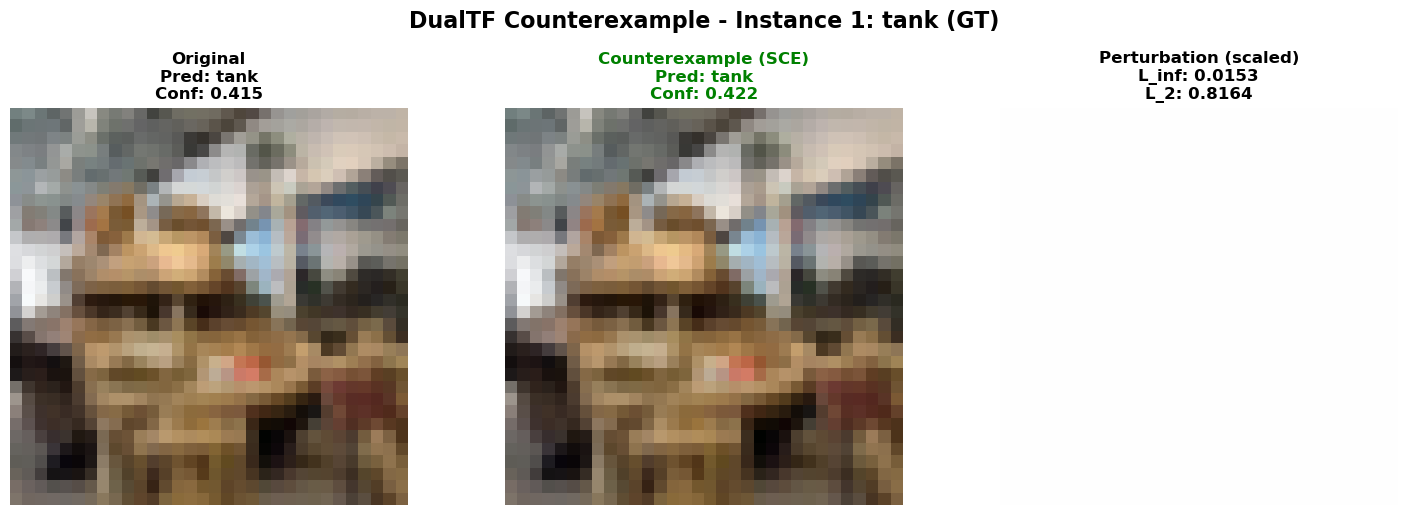


SUMMARY
Instance: 1/3
True label: 85 (tank)
Epsilon: 0.030590

DualTF Results:
  Min margin: -2.224983
  Certified: False
  Weakest class: 99 (worm)

Counterexample:
  Original pred: 85 (tank)
  SCE pred: 85 (tank)
  Misclassified: False
  L_inf perturbation: 0.015295
  Within epsilon: True


In [12]:
def denormalize_cifar100(img_tensor):
    """Denormalize CIFAR-100 image for visualization"""
    mean = torch.tensor([0.5071, 0.4867, 0.4408]).view(1, 3, 1, 1)
    std = torch.tensor([0.2675, 0.2565, 0.2761]).view(1, 3, 1, 1)
    img = img_tensor * std + mean
    return img.clamp(0, 1)

# Prepare images for visualization
orig_img = denormalize_cifar100(input_tensor.cpu())
sce_img = denormalize_cifar100(sce_image.cpu())
diff_img = (sce_img - orig_img).abs()

# Scale difference for better visibility
diff_img_scaled = diff_img / (diff_img.max() + 1e-8)

# Convert to numpy for plotting
orig_np = orig_img[0].permute(1, 2, 0).numpy()
sce_np = sce_img[0].permute(1, 2, 0).numpy()
diff_np = diff_img_scaled[0].permute(1, 2, 0).numpy()

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(orig_np)
axes[0].set_title(f"Original\nPred: {CIFAR100_CLASSES[orig_pred]}\nConf: {orig_confidence:.3f}", 
                  fontsize=12, fontweight='bold')
axes[0].axis('off')

# Counterexample
axes[1].imshow(sce_np)
color = 'red' if sce_pred != true_label else 'green'
axes[1].set_title(f"Counterexample (SCE)\nPred: {CIFAR100_CLASSES[sce_pred]}\nConf: {sce_confidence:.3f}",
                  fontsize=12, fontweight='bold', color=color)
axes[1].axis('off')

# Difference (perturbation)
axes[2].imshow(diff_np)
axes[2].set_title(f"Perturbation (scaled)\nL_inf: {l_inf:.4f}\nL_2: {l_2:.4f}",
                  fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f"DualTF Counterexample - Instance {INSTANCE_IDX + 1}: {CIFAR100_CLASSES[true_label]} (GT)",
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Instance: {INSTANCE_IDX + 1}/{len(instance_info)}")
print(f"True label: {true_label} ({CIFAR100_CLASSES[true_label]})")
print(f"Epsilon: {epsilon:.6f}")
print(f"\nDualTF Results:")
print(f"  Min margin: {min_margin.item():.6f}")
print(f"  Certified: {is_certified}")
print(f"  Weakest class: {weakest_class} ({CIFAR100_CLASSES[weakest_class]})")
print(f"\nCounterexample:")
print(f"  Original pred: {orig_pred} ({CIFAR100_CLASSES[orig_pred]})")
print(f"  SCE pred: {sce_pred} ({CIFAR100_CLASSES[sce_pred]})")
print(f"  Misclassified: {sce_pred != true_label}")
print(f"  L_inf perturbation: {l_inf:.6f}")
print(f"  Within epsilon: {l_inf <= epsilon}")

## Step 11: Batch Process All Instances

In [13]:
print("="*80)
print("BATCH PROCESSING ALL INSTANCES")
print("="*80)

all_results = []

for idx in range(len(instance_info)):
    print(f"\n--- Instance {idx + 1}/{len(instance_info)} ---")
    
    info = instance_info[idx]
    wrapped_model = wrapped_models_list[idx]
    true_label = info['true_label']
    input_tensor = info['input_tensor']
    
    # Convert to ACT
    converter = TorchToACT(wrapped_model)
    act_net = converter.run()
    
    # Compute forward bounds
    
    # Get input bounds from specification
    input_spec = info['input_spec']
    input_lb = input_spec.lb.flatten()
    input_ub = input_spec.ub.flatten()
    bounds_dict = compute_forward_bounds(act_net, input_lb, input_ub)
    
    # Get output bounds
    output_layer = act_net.layers[-2]
    output_bounds = bounds_dict.get(output_layer.id)
    
    # DualTF verification
    dual_tf = DualTF()
    min_margin, is_certified = dual_tf.compute_robust_bound(act_net, bounds_dict, true_label, num_classes)
    
    # Find weakest class
    margins = []
    for target_class in range(num_classes):
        if target_class == true_label:
            continue
        c = torch.zeros(num_classes, dtype=output_bounds.lb.dtype, device=output_bounds.lb.device)
        c[true_label] = 1.0
        c[target_class] = -1.0
        margin = dual_tf.compute_bound(act_net, bounds_dict, c)
        margins.append((target_class, margin.item()))
    
    margins.sort(key=lambda x: x[1])
    weakest_class, weakest_margin = margins[0]
    
    # Generate SCE
    c = torch.zeros(num_classes, dtype=output_bounds.lb.dtype, device=output_bounds.lb.device)
    c[true_label] = 1.0
    c[weakest_class] = -1.0
    margin, sce_raw = dual_tf.compute_bound(act_net, bounds_dict, c, return_sce=True)
    
    # Reconstruct SCE if needed
    expected_size = 3 * 32 * 32
    if sce_raw.numel() != expected_size:
        input_layer = act_net.layers[1]
        input_bounds = bounds_dict.get(input_layer.id)
        sce_image = input_bounds.lb.clone().reshape(1, 3, 32, 32) if input_bounds else input_tensor.clone()
    else:
        sce_image = sce_raw.reshape(1, 3, 32, 32)
    
    # Validate
    pytorch_model = wrapped_model[2]
    pytorch_model.eval()
    
    with torch.no_grad():
        orig_output = pytorch_model(input_tensor)
        orig_pred = orig_output.argmax(dim=1).item()
        
        sce_output = pytorch_model(sce_image)
        sce_pred = sce_output.argmax(dim=1).item()
    
    perturbation = (sce_image - input_tensor).abs()
    l_inf = perturbation.max().item()
    
    result = {
        'index': idx,
        'true_label': true_label,
        'class_name': CIFAR100_CLASSES[true_label],
        'is_certified': is_certified,
        'min_margin': min_margin.item(),
        'weakest_class': weakest_class,
        'weakest_margin': weakest_margin,
        'orig_pred': orig_pred,
        'sce_pred': sce_pred,
        'misclassified': sce_pred != true_label,
        'l_inf': l_inf,
        'sce_image': sce_image
    }
    all_results.append(result)
    
    status = "✓ COUNTEX" if result['misclassified'] else "✗ SPURIOUS"
    cert_status = "CERT" if is_certified else "UNCERT"
    print(f"  {CIFAR100_CLASSES[true_label]:15s} | {cert_status:6s} | Margin: {min_margin.item():7.4f} | {status}")

print("\n" + "="*80)
print("BATCH RESULTS SUMMARY")
print("="*80)
print(f"Total instances: {len(all_results)}")
print(f"Certified robust: {sum(r['is_certified'] for r in all_results)}")
print(f"Real counterexamples found: {sum(r['misclassified'] for r in all_results)}")
print(f"Spurious counterexamples: {sum(not r['misclassified'] for r in all_results)}")

BATCH PROCESSING ALL INSTANCES

--- Instance 1/3 ---
  tank            | UNCERT | Margin: -2.2250 | ✗ SPURIOUS

--- Instance 2/3 ---
  shrew           | UNCERT | Margin: -1.8028 | ✗ SPURIOUS

--- Instance 3/3 ---
  table           | UNCERT | Margin: -1.1100 | ✗ SPURIOUS

BATCH RESULTS SUMMARY
Total instances: 3
Certified robust: 0
Real counterexamples found: 0
Spurious counterexamples: 3


## Step 12: Visualize All Counterexamples

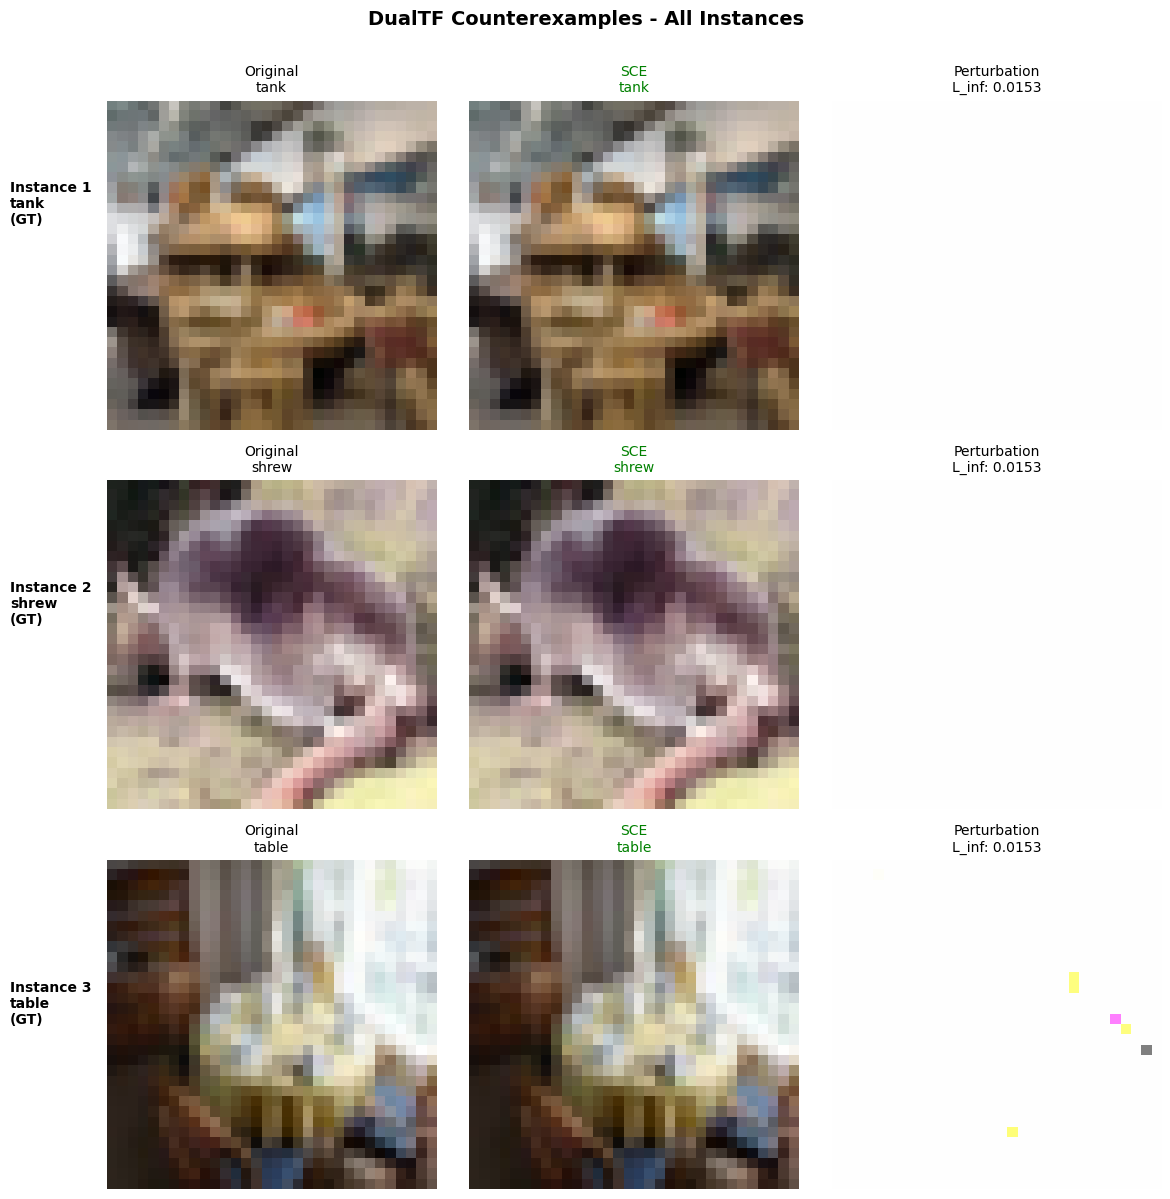


Visualization complete!


In [14]:
# Visualize all instances
n_instances = len(all_results)
fig, axes = plt.subplots(n_instances, 3, figsize=(12, 4 * n_instances))

if n_instances == 1:
    axes = axes.reshape(1, -1)

for idx, result in enumerate(all_results):
    info = instance_info[idx]
    orig_tensor = info['input_tensor']
    sce_tensor = result['sce_image']
    
    # Denormalize
    orig_img = denormalize_cifar100(orig_tensor.cpu())
    sce_img = denormalize_cifar100(sce_tensor.cpu())
    diff_img = (sce_img - orig_img).abs()
    diff_img_scaled = diff_img / (diff_img.max() + 1e-8)
    
    # Convert to numpy
    orig_np = orig_img[0].permute(1, 2, 0).numpy()
    sce_np = sce_img[0].permute(1, 2, 0).numpy()
    diff_np = diff_img_scaled[0].permute(1, 2, 0).numpy()
    
    # Plot
    axes[idx, 0].imshow(orig_np)
    axes[idx, 0].set_title(f"Original\n{CIFAR100_CLASSES[result['orig_pred']]}", fontsize=10)
    axes[idx, 0].axis('off')
    
    color = 'red' if result['misclassified'] else 'green'
    axes[idx, 1].imshow(sce_np)
    axes[idx, 1].set_title(f"SCE\n{CIFAR100_CLASSES[result['sce_pred']]}", fontsize=10, color=color)
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(diff_np)
    axes[idx, 2].set_title(f"Perturbation\nL_inf: {result['l_inf']:.4f}", fontsize=10)
    axes[idx, 2].axis('off')
    
    # Add row label
    fig.text(0.02, 1 - (idx + 0.5) / n_instances, 
             f"Instance {idx + 1}\n{CIFAR100_CLASSES[result['true_label']]}\n(GT)",
             va='center', ha='left', fontsize=10, fontweight='bold')

plt.suptitle('DualTF Counterexamples - All Instances', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0.08, 0, 1, 0.99])
plt.show()

print("\nVisualization complete!")